In [4]:
!curl -L -o Gridworld.py https://github.com/DeepReinforcementLearning/DeepReinforcementLearningInAction/raw/master/Errata/Gridworld.py
!curl -L -o GridBoard.py https://github.com/DeepReinforcementLearning/DeepReinforcementLearningInAction/raw/master/Errata/GridBoard.py


  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed

  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0

100  4915  100  4915    0     0   4791      0  0:00:01  0:00:01 --:--:--  4791
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed

  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0

100  2576  100  2576    0     0   3053      0 --:--:-- --:--:-- --:--:--  3053


In [5]:
import os
print(os.getcwd())
print(os.listdir())


c:\Users\User\learn_ML
['.ipynb_checkpoints', '.vscode', 'env_kernel_test.ipynb', 'GridBoard.py', 'Gridworld.py', 'gridworld_RL.ipynb', '多臂拉霸機_RL.ipynb']


In [6]:
from Gridworld import Gridworld
game = Gridworld(size=4, mode='static')

In [ ]:
game.display() #+終點-陷阱W牆壁P玩家

array([['+', '-', ' ', 'P'],
       [' ', 'W', ' ', ' '],
       [' ', ' ', ' ', ' '],
       [' ', ' ', ' ', ' ']], dtype='<U2')

In [13]:
game.makeMove('d')#u,d,l,r
print("reward:", game.reward())
game.display() #+終點-陷阱W牆壁P玩家

reward: -1


array([['+', '-', ' ', ' '],
       [' ', 'W', ' ', 'P'],
       [' ', ' ', ' ', ' '],
       [' ', ' ', ' ', ' ']], dtype='<U2')

In [18]:
game.board.render_np()

array([[[0, 0, 0, 0],
        [0, 0, 0, 1],
        [0, 0, 0, 0],
        [0, 0, 0, 0]],

       [[1, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0]],

       [[0, 1, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0]],

       [[0, 0, 0, 0],
        [0, 1, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0]]], dtype=uint8)

In [26]:
import numpy as np
import torch
from IPython.display import clear_output
import matplotlib.pyplot as plt
import random
#nn as agent

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("using:", device)

model = torch.nn.Sequential(
    torch.nn.Linear(64, 256),#4*4*4=64
    torch.nn.ReLU(),
    torch.nn.Linear(256, 128),
    torch.nn.ReLU(),
    torch.nn.Linear(128, 4)
).to(device)
loss_fn = torch.nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

gamma = 0.9
epsilon = 0.1

using: cuda


ep  100 | loss=12.3888 | reward=-50.0
ep  200 | loss=0.0056 | reward=4.0
ep  300 | loss=0.1165 | reward=4.0
ep  400 | loss=0.0464 | reward=4.0
ep  500 | loss=0.1083 | reward=4.0
ep  600 | loss=0.3400 | reward=4.0
ep  700 | loss=0.0309 | reward=4.0
ep  800 | loss=3.6007 | reward=1.0
ep  900 | loss=1.8225 | reward=0.0
ep 1000 | loss=0.0397 | reward=4.0
training done


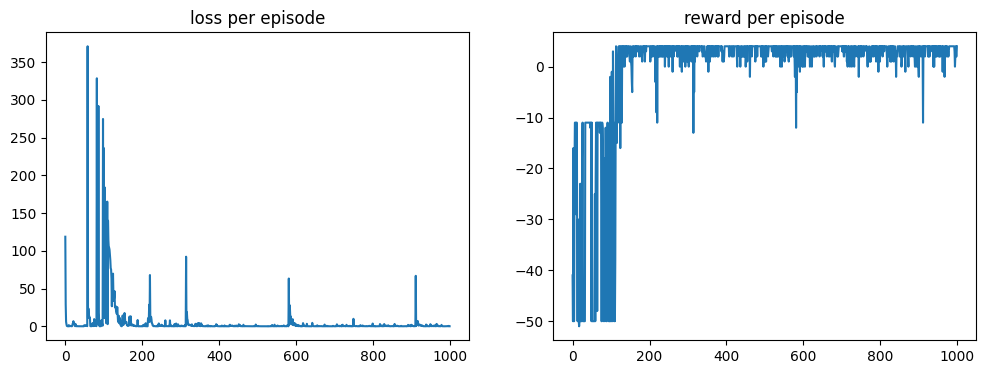

In [27]:

episodes = 1000
max_steps = 50
action_set = {0: 'u', 1: 'd', 2: 'l', 3: 'r'}

losses = []
rewards = []

for ep in range(episodes):
    game = Gridworld(size=4, mode='static')

    s_np = game.board.render_np().reshape(1, 64).astype(np.float32)
    state = torch.from_numpy(s_np).to(device)

    ep_loss = 0.0
    ep_reward = 0.0

    for t in range(max_steps):
        # epsilon-greedy
        if random.random() < epsilon:
            action = random.randint(0, 3)
        else:
            with torch.no_grad():
                qvals = model(state)
                action = torch.argmax(qvals, dim=1).item()

        game.makeMove(action_set[action])
        reward = game.reward()
        ep_reward += reward
        done = reward in (-10, 10)

        ns_np = game.board.render_np().reshape(1, 64).astype(np.float32)
        next_state = torch.from_numpy(ns_np).to(device)

        with torch.no_grad():
            max_next_q = model(next_state).max(dim=1)[0].item()

        target = reward if done else reward + gamma * max_next_q
        target = torch.tensor(target, dtype=torch.float32, device=device)

        pred_all = model(state)
        pred = pred_all[0, action]

        loss = loss_fn(pred, target)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        ep_loss += loss.item()
        state = next_state

        if done:
            break

    losses.append(ep_loss)
    rewards.append(ep_reward)

    if (ep + 1) % 100 == 0:
        print(f"ep {ep+1:4d} | loss={ep_loss:.4f} | reward={ep_reward:.1f}")

print("training done")

# plot
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(losses)
plt.title("loss per episode")
plt.subplot(1,2,2)
plt.plot(rewards)
plt.title("reward per episode")
plt.show()


In [29]:
test_game = Gridworld(size=4, mode='static')
print("initial:")
print(test_game.display())

state = torch.from_numpy(test_game.board.render_np().reshape(1,64).astype(np.float32)).to(device)

for i in range(20):
    with torch.no_grad():
        action = torch.argmax(model(state), dim=1).item()
    test_game.makeMove(action_set[action])
    r = test_game.reward()
    print(f"step {i+1}, action={action_set[action]}, reward={r}")
    print(test_game.display())
    if r in (-10, 10):
        break
    state = torch.from_numpy(test_game.board.render_np().reshape(1,64).astype(np.float32)).to(device)


initial:
[['+' '-' ' ' 'P']
 [' ' 'W' ' ' ' ']
 [' ' ' ' ' ' ' ']
 [' ' ' ' ' ' ' ']]
step 1, action=l, reward=-1
[['+' '-' 'P' ' ']
 [' ' 'W' ' ' ' ']
 [' ' ' ' ' ' ' ']
 [' ' ' ' ' ' ' ']]
step 2, action=d, reward=-1
[['+' '-' ' ' ' ']
 [' ' 'W' 'P' ' ']
 [' ' ' ' ' ' ' ']
 [' ' ' ' ' ' ' ']]
step 3, action=d, reward=-1
[['+' '-' ' ' ' ']
 [' ' 'W' ' ' ' ']
 [' ' ' ' 'P' ' ']
 [' ' ' ' ' ' ' ']]
step 4, action=l, reward=-1
[['+' '-' ' ' ' ']
 [' ' 'W' ' ' ' ']
 [' ' 'P' ' ' ' ']
 [' ' ' ' ' ' ' ']]
step 5, action=l, reward=-1
[['+' '-' ' ' ' ']
 [' ' 'W' ' ' ' ']
 ['P' ' ' ' ' ' ']
 [' ' ' ' ' ' ' ']]
step 6, action=u, reward=-1
[['+' '-' ' ' ' ']
 ['P' 'W' ' ' ' ']
 [' ' ' ' ' ' ' ']
 [' ' ' ' ' ' ' ']]
step 7, action=u, reward=10
[['+' '-' ' ' ' ']
 [' ' 'W' ' ' ' ']
 [' ' ' ' ' ' ' ']
 [' ' ' ' ' ' ' ']]
